# UNIVERSIDAD PRIVADA BOLIVIANA - DIPLOMADO: ANALÍTICA GERENCIAL ORIENTADO A LA TOMA DE DECISIONES CON POWER BI Y PYTHON

## Trabajo final - ANÁLISIS AVANZADO CON POWER BI Y PYTHON

# Predicción de Depresión Adolescente usando Machine Learning

### Estudiante:
Nicolas Rivera

### Docente:
Ariel Lopez

### Materia:
Análisis Avanzado con Power BI y Python

### Fecha:
24/05/26

# Introducción

La salud mental adolescente se ha convertido en una problemática importante debido al incremento del uso de redes sociales, estrés académico y hábitos digitales poco saludables.

El presente trabajo tiene como objetivo analizar factores relacionados con la depresión adolescente utilizando técnicas de análisis predictivo y Machine Learning.

A través del análisis exploratorio y la construcción de un modelo de clasificación, se busca identificar patrones que permitan predecir posibles casos de depresión.

## Nota

Para ejecutar correctamente este notebook, el archivo `Teen_Mental_Health_Dataset.csv` debe encontrarse en la misma carpeta que el archivo `.ipynb`.

# Objetivos

## Objetivo General

Desarrollar un modelo predictivo capaz de identificar posibles casos de depresión adolescente utilizando variables relacionadas con hábitos digitales y comportamiento social.

## Objetivos Específicos

- Realizar análisis exploratorio del dataset.
- Identificar variables relacionadas con depresión.
- Construir un modelo predictivo utilizando Random Forest.
- Evaluar el desempeño del modelo.
- Proponer recomendaciones basadas en los resultados obtenidos.

# Importación de Librerías

En esta sección se importan las librerías necesarias para el análisis de datos, visualización y construcción del modelo predictivo.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Carga del Dataset

Se carga el dataset que contiene información relacionada con salud mental adolescente, hábitos digitales, estrés y niveles de depresión.

In [45]:
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'Teen_Mental_Health_Dataset.csv'

In [22]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


# Exploración Inicial del Dataset

En esta sección se analiza la estructura general del dataset, tipos de datos y presencia de valores nulos.

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [24]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [25]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

# Limpieza de Datos

Se eliminan valores nulos y registros duplicados para mejorar la calidad del análisis y evitar errores en el modelo predictivo.

In [28]:
df = df.dropna()

In [29]:
df = df.drop_duplicates()

# Análisis Exploratorio de Datos

El análisis exploratorio permite identificar patrones, tendencias y relaciones entre variables relacionadas con la depresión adolescente.

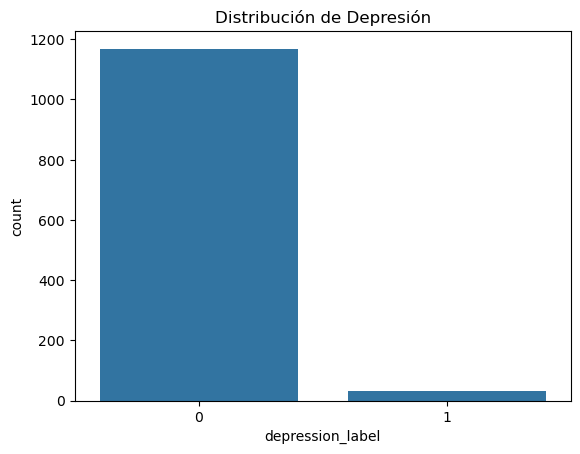

In [30]:
sns.countplot(x='depression_label', data=df)
plt.title("Distribución de Depresión")
plt.show()

## Interpretación del gráfico

El gráfico muestra la distribución de adolescentes con y sin depresión dentro del dataset.

La variable `depression_label` utiliza:
- 0 = No presenta depresión
- 1 = Presenta depresión

Esto permite trabajar con un problema de clasificación binaria, donde el modelo debe predecir una de dos posibles categorías.

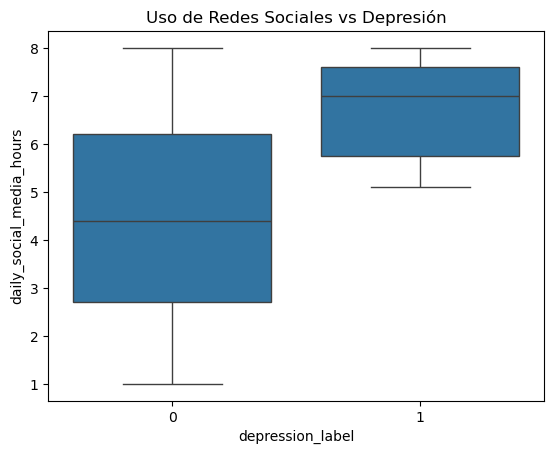

In [31]:
sns.boxplot(x='depression_label', y='daily_social_media_hours', data=df)
plt.title("Uso de Redes Sociales vs Depresión")
plt.show()

## Interpretación del gráfico

El boxplot permite comparar las horas de uso de redes sociales entre adolescentes con y sin depresión.

Se observa que los adolescentes con depresión tienden a presentar un mayor uso diario de redes sociales.

La línea central representa la mediana y la caja contiene el 50% central de los datos.

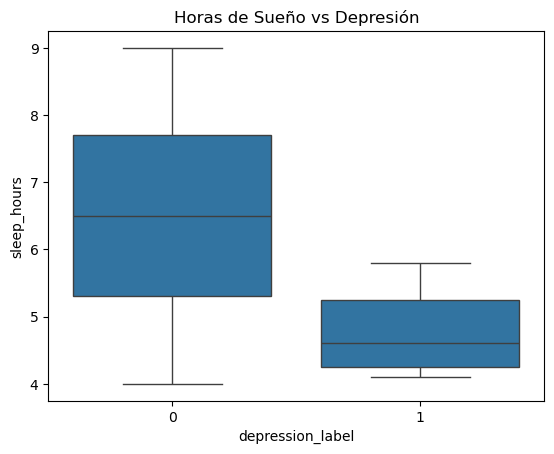

In [32]:
sns.boxplot(x='depression_label', y='sleep_hours', data=df)
plt.title("Horas de Sueño vs Depresión")
plt.show()

## Interpretación del gráfico

El gráfico muestra la relación entre horas de sueño y depresión adolescente.

Se observa que los adolescentes con depresión presentan menores horas de sueño en comparación con quienes no presentan depresión.

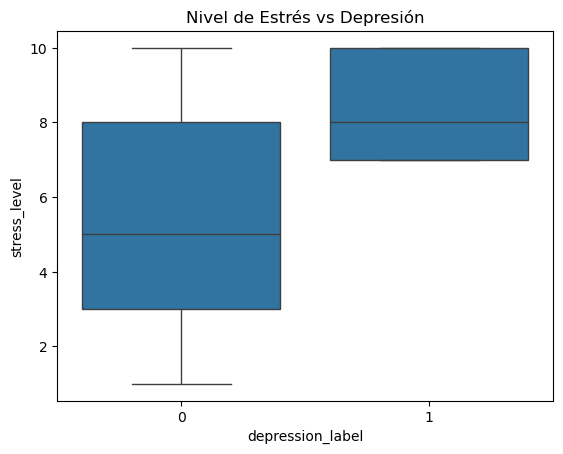

In [33]:
sns.boxplot(x='depression_label', y='stress_level', data=df)
plt.title("Nivel de Estrés vs Depresión")
plt.show()

## Interpretación del gráfico

El nivel de estrés presenta una relación importante con la depresión adolescente.

Los adolescentes con depresión muestran niveles de estrés considerablemente más elevados.

# Codificación de Variables

Las variables categóricas fueron transformadas a formato numérico utilizando LabelEncoder.

Esto se debe a que los algoritmos de Machine Learning trabajan principalmente con datos numéricos.

Por ejemplo:
- Male → 0
- Female → 1

La variable objetivo también utiliza:
- 0 = No depresión
- 1 = Depresión

In [34]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Mapa de Correlación

El mapa de correlación permite identificar relaciones entre variables y determinar cuáles tienen mayor influencia sobre la depresión adolescente.

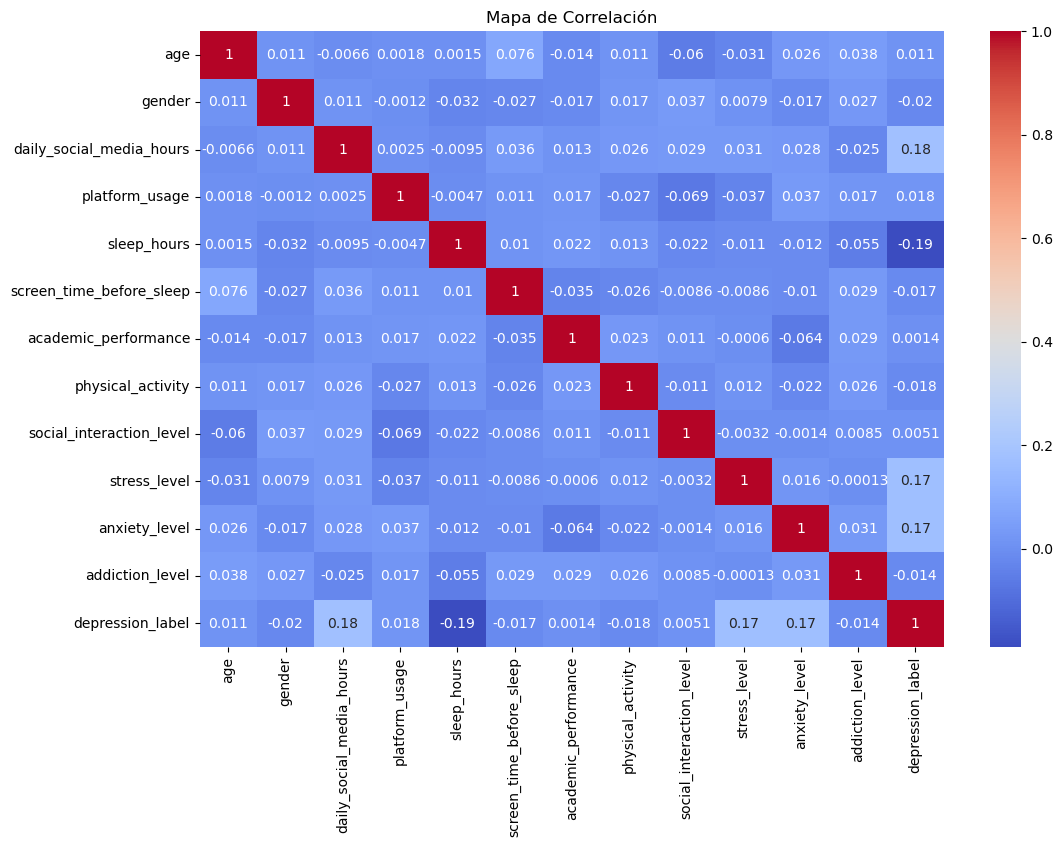

In [35]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Mapa de Correlación")
plt.show()

## Interpretación del mapa de correlación

El mapa de correlación permite identificar relaciones entre variables.

Las correlaciones positivas indican que ambas variables aumentan juntas, mientras que las negativas indican relaciones inversas.

Se observa que variables como ansiedad, estrés y adicción digital presentan una fuerte relación con la depresión adolescente.

In [36]:
X = df.drop('depression_label', axis=1)

In [37]:
y = df['depression_label']

# División de Datos

El dataset fue dividido en datos de entrenamiento y prueba.

- 80% de los datos fueron utilizados para entrenar el modelo.
- 20% fueron utilizados para evaluar el desempeño predictivo.

Esto permite comprobar si el modelo puede realizar predicciones correctas sobre datos nuevos.

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Modelo Predictivo: Random Forest

Se utilizó el algoritmo Random Forest debido a su capacidad para identificar patrones complejos y ofrecer alta precisión en problemas de clasificación.

Este algoritmo funciona mediante múltiples árboles de decisión, donde cada árbol realiza una predicción y el resultado final se obtiene mediante votación.

In [39]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
y_pred = model.predict(X_test)

In [25]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9791666666666666


## Interpretación del Accuracy

El accuracy representa el porcentaje de predicciones correctas realizadas por el modelo.

Un valor elevado (97,92%) indica que el modelo tiene buen desempeño para identificar casos de depresión adolescente.

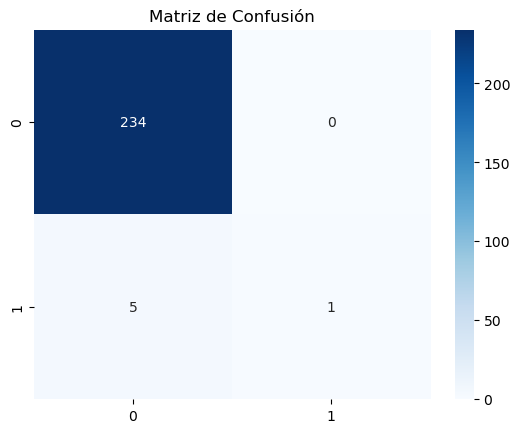

In [41]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.show()

## Interpretación de la matriz de confusión

La matriz de confusión permite analizar los aciertos y errores del modelo predictivo.

Los valores de la diagonal representan predicciones correctas, mientras que los demás valores representan errores de clasificación.

In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       234
           1       1.00      0.17      0.29         6

    accuracy                           0.98       240
   macro avg       0.99      0.58      0.64       240
weighted avg       0.98      0.98      0.97       240



## Interpretación del reporte de clasificación

El reporte de clasificación incluye métricas como precisión, recall y F1-score.

Estas métricas permiten evaluar qué tan efectivo es el modelo para detectar correctamente casos de depresión.

# Variables Más Importantes

En esta sección se analizan las variables que tuvieron mayor influencia en las predicciones realizadas por el modelo Random Forest.

In [43]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importance
})

feature_importance = feature_importance.sort_values(
    by='Importancia',
    ascending=False
)

print(feature_importance)

                    Variable  Importancia
4                sleep_hours     0.200609
2   daily_social_media_hours     0.189218
9               stress_level     0.152071
10             anxiety_level     0.139791
6       academic_performance     0.058888
11           addiction_level     0.057676
5   screen_time_before_sleep     0.057419
7          physical_activity     0.050607
0                        age     0.033133
8   social_interaction_level     0.026430
1                     gender     0.018821
3             platform_usage     0.015338


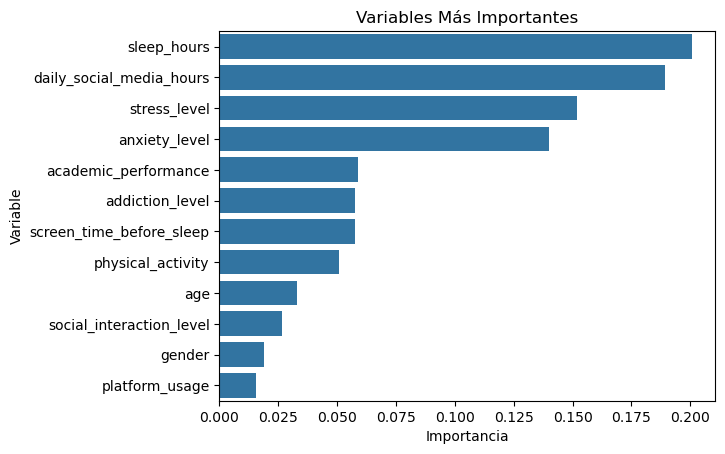

In [44]:
sns.barplot(
    x='Importancia',
    y='Variable',
    data=feature_importance
)

plt.title("Variables Más Importantes")
plt.show()

## Interpretación del gráfico

Las variables con mayor importancia tienen mayor influencia en la predicción de depresión adolescente.

Factores como ansiedad, estrés y uso excesivo de redes sociales destacan como variables relevantes dentro del modelo.

# Conclusión académica

El análisis permitió identificar que los factores más relacionados con la depresión adolescente son el nivel de ansiedad, el estrés y el uso excesivo de redes sociales.

El modelo Random Forest logró una precisión satisfactoria para predecir posibles casos de depresión.

Como medida prescriptiva, se recomienda implementar programas de apoyo psicológico y educación digital para reducir el impacto negativo del uso excesivo de redes sociales en adolescentes.

# Recomendaciones

A partir de los resultados obtenidos, se recomienda:

- Implementar programas de apoyo psicológico preventivo.
- Promover hábitos saludables de sueño.
- Fomentar el uso responsable de redes sociales.
- Desarrollar campañas de salud mental en instituciones educativas.
- Detectar tempranamente altos niveles de ansiedad y estrés.